# Before you start:
- Read the README.md file
- Comment as much as you can and use the resources in the README.md file
- Happy learning!

In [12]:
# Import your libraries:

%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

In this lab, we will explore a dataset that describes websites with different features and labels them either benign or malicious . We will use supervised learning algorithms to figure out what feature patterns malicious websites are likely to have and use our model to predict malicious websites.

# Challenge 1 - Explore The Dataset

Let's start by exploring the dataset. First load the data file:

In [3]:
websites = pd.read_csv('../data/website.csv')

#### Explore the data from an bird's-eye view.

You should already been very familiar with the procedures now so we won't provide the instructions step by step. Reflect on what you did in the previous labs and explore the dataset.

Things you'll be looking for:

* What the dataset looks like?
* What are the data types?
* Which columns contain the features of the websites?
* Which column contains the feature we will predict? What is the code standing for benign vs malicious websites?
* Do we need to transform any of the columns from categorical to ordinal values? If so what are these columns?

Feel free to add additional cells for more exploration. Make sure to comment what you find!

In [3]:
# Your code here
print(websites)


          URL  URL_LENGTH  NUMBER_SPECIAL_CHARACTERS     CHARSET  \
0      M0_109          16                          7  iso-8859-1   
1     B0_2314          16                          6       UTF-8   
2      B0_911          16                          6    us-ascii   
3      B0_113          17                          6  ISO-8859-1   
4      B0_403          17                          6       UTF-8   
...       ...         ...                        ...         ...   
1776    M4_48         194                         16       UTF-8   
1777    M4_41         198                         17       UTF-8   
1778   B0_162         201                         34       utf-8   
1779  B0_1152         234                         34  ISO-8859-1   
1780   B0_676         249                         40       utf-8   

                      SERVER  CONTENT_LENGTH WHOIS_COUNTRY WHOIS_STATEPRO  \
0                      nginx           263.0           NaN            NaN   
1              Apache/2.4.10 

In [4]:
websites

,URL,URL_LENGTH,NUMBER_SPECIAL_CHARACTERS,CHARSET,SERVER,CONTENT_LENGTH,WHOIS_COUNTRY,WHOIS_STATEPRO,WHOIS_REGDATE,WHOIS_UPDATED_DATE,...,DIST_REMOTE_TCP_PORT,REMOTE_IPS,APP_BYTES,SOURCE_APP_PACKETS,REMOTE_APP_PACKETS,SOURCE_APP_BYTES,REMOTE_APP_BYTES,APP_PACKETS,DNS_QUERY_TIMES,Type
0,M0_109,16,7,iso-8859-1,nginx,263.0,NaN,NaN,10/10/2015 18:21,NaN,...,0,2,700,9,10,1153,832,9,2.0,1
1,B0_2314,16,6,UTF-8,Apache/2.4.10,15087.0,NaN,NaN,NaN,NaN,...,7,4,1230,17,19,1265,1230,17,0.0,0
2,B0_911,16,6,us-ascii,Microsoft-HTTPAPI/2.0,324.0,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0.0,0
3,B0_113,17,6,ISO-8859-1,nginx,162.0,US,AK,7/10/1997 4:00,12/09/2013 0:45,...,22,3,3812,39,37,18784,4380,39,8.0,0
4,B0_403,17,6,UTF-8,NaN,124140.0,US,TX,12/05/1996 0:00,11/04/2017 0:00,...,2,5,4278,61,62,129889,4586,61,4.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1776,M4_48,194,16,UTF-8,Apache,NaN,ES,Barcelona,17/09/2008 0:00,2/09/2016 0:00,...,0,0,0,0,3,186,0,0,0.0,1
1777,M4_41,198,17,UTF-8,Apache,NaN,ES,Barcelona,17/09/2008 0:00,2/09/2016 0:00,...,0,0,0,0,2,124,0,0,0.0,1
1778,B0_162,201,34,utf-8,Apache/2.2.16 (Debian),8904.0,US,FL,15/02/1999 0:00,15/07/2015 0:00,...,2,6,6631,87,89,132181,6945,87,4.0,0
1779,B0_1152,234,34,ISO-8859-1,cloudflare-nginx,NaN,US,CA,1/04/1998 0:00,9/12/2016 0:00,...,0,0,0,0,0,0,0,0,0.0,0


In [5]:
websites.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1781 entries, 0 to 1780
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   URL                        1781 non-null   object 
 1   URL_LENGTH                 1781 non-null   int64  
 2   NUMBER_SPECIAL_CHARACTERS  1781 non-null   int64  
 3   CHARSET                    1774 non-null   object 
 4   SERVER                     1605 non-null   object 
 5   CONTENT_LENGTH             969 non-null    float64
 6   WHOIS_COUNTRY              1475 non-null   object 
 7   WHOIS_STATEPRO             1419 non-null   object 
 8   WHOIS_REGDATE              1654 non-null   object 
 9   WHOIS_UPDATED_DATE         1642 non-null   object 
 10  TCP_CONVERSATION_EXCHANGE  1781 non-null   int64  
 11  DIST_REMOTE_TCP_PORT       1781 non-null   int64  
 12  REMOTE_IPS                 1781 non-null   int64  
 13  APP_BYTES                  1781 non-null   int64

In [6]:
websites.describe()

,URL_LENGTH,NUMBER_SPECIAL_CHARACTERS,CONTENT_LENGTH,TCP_CONVERSATION_EXCHANGE,DIST_REMOTE_TCP_PORT,REMOTE_IPS,APP_BYTES,SOURCE_APP_PACKETS,REMOTE_APP_PACKETS,SOURCE_APP_BYTES,REMOTE_APP_BYTES,APP_PACKETS,DNS_QUERY_TIMES,Type
count,1781.000000,1781.000000,969.000000,1781.000000,1781.000000,1781.000000,1.781000e+03,1781.000000,1781.000000,1.781000e+03,1.781000e+03,1781.000000,1780.000000,1781.000000
mean,56.961258,11.111735,11726.927761,16.261089,5.472768,3.060640,2.982339e+03,18.540146,18.746210,1.589255e+04,3.155599e+03,18.540146,2.263483,0.121280
std,27.555586,4.549896,36391.809051,40.500975,21.807327,3.386975,5.605057e+04,41.627173,46.397969,6.986193e+04,5.605378e+04,41.627173,2.930853,0.326544
min,16.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000
25%,39.000000,8.000000,324.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000
50%,49.000000,10.000000,1853.000000,7.000000,0.000000,2.000000,6.720000e+02,8.000000,9.000000,5.790000e+02,7.350000e+02,8.000000,0.000000,0.000000
75%,68.000000,13.000000,11323.000000,22.000000,5.000000,5.000000,2.328000e+03,26.000000,25.000000,9.806000e+03,2.701000e+03,26.000000,4.000000,0.000000
max,249.000000,43.000000,649263.000000,1194.000000,708.000000,17.000000,2.362906e+06,1198.000000,1284.000000,2.060012e+06,2.362906e+06,1198.000000,20.000000,1.000000


In [7]:
websites.isnull().sum()

URL                            0
URL_LENGTH                     0
NUMBER_SPECIAL_CHARACTERS      0
CHARSET                        7
SERVER                       176
CONTENT_LENGTH               812
WHOIS_COUNTRY                306
WHOIS_STATEPRO               362
WHOIS_REGDATE                127
WHOIS_UPDATED_DATE           139
TCP_CONVERSATION_EXCHANGE      0
DIST_REMOTE_TCP_PORT           0
REMOTE_IPS                     0
APP_BYTES                      0
SOURCE_APP_PACKETS             0
REMOTE_APP_PACKETS             0
SOURCE_APP_BYTES               0
REMOTE_APP_BYTES               0
APP_PACKETS                    0
DNS_QUERY_TIMES                1
Type                           0
dtype: int64

In [8]:
# Your comment here
type(websites)

pandas.core.frame.DataFrame

#### Next, evaluate if the columns in this dataset are strongly correlated.

In class, we discussed that we are concerned if our dataset has strongly correlated columns because if this is the case we need to choose certain ML algorithms instead of others. We need to evaluate this for our dataset now.

Luckily, most of the columns in this dataset are ordinal which makes things a lot easier for us. In the cells below, evaluate the level of collinearity of the data.

We provide some general directions for you to consult in order to complete this step:

1. You will create a correlation matrix using the numeric columns in the dataset.

1. Create a heatmap using `seaborn` to visualize which columns have high collinearity.

1. Comment on which columns you might need to remove due to high collinearity.

In [9]:
# Your code here
import seaborn as sns

In [10]:
# Seleccionar solo columnas numéricas
numeric_cols = websites.select_dtypes(include=np.number)
numeric_cols

,URL_LENGTH,NUMBER_SPECIAL_CHARACTERS,CONTENT_LENGTH,TCP_CONVERSATION_EXCHANGE,DIST_REMOTE_TCP_PORT,REMOTE_IPS,APP_BYTES,SOURCE_APP_PACKETS,REMOTE_APP_PACKETS,SOURCE_APP_BYTES,REMOTE_APP_BYTES,APP_PACKETS,DNS_QUERY_TIMES,Type
0,16,7,263.0,7,0,2,700,9,10,1153,832,9,2.0,1
1,16,6,15087.0,17,7,4,1230,17,19,1265,1230,17,0.0,0
2,16,6,324.0,0,0,0,0,0,0,0,0,0,0.0,0
3,17,6,162.0,31,22,3,3812,39,37,18784,4380,39,8.0,0
4,17,6,124140.0,57,2,5,4278,61,62,129889,4586,61,4.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1776,194,16,NaN,0,0,0,0,0,3,186,0,0,0.0,1
1777,198,17,NaN,0,0,0,0,0,2,124,0,0,0.0,1
1778,201,34,8904.0,83,2,6,6631,87,89,132181,6945,87,4.0,0
1779,234,34,NaN,0,0,0,0,0,0,0,0,0,0.0,0


In [11]:
correlation_matrix = numeric_cols.corr()
print(correlation_matrix)

                           URL_LENGTH  NUMBER_SPECIAL_CHARACTERS  \
URL_LENGTH                   1.000000                   0.917986   
NUMBER_SPECIAL_CHARACTERS    0.917986                   1.000000   
CONTENT_LENGTH               0.129745                   0.214225   
TCP_CONVERSATION_EXCHANGE   -0.038407                  -0.037459   
DIST_REMOTE_TCP_PORT        -0.039839                  -0.042619   
REMOTE_IPS                  -0.046367                  -0.047103   
APP_BYTES                   -0.026446                  -0.023914   
SOURCE_APP_PACKETS          -0.042264                  -0.040096   
REMOTE_APP_PACKETS          -0.033779                  -0.030597   
SOURCE_APP_BYTES            -0.014857                  -0.014376   
REMOTE_APP_BYTES            -0.026686                  -0.024098   
APP_PACKETS                 -0.042264                  -0.040096   
DNS_QUERY_TIMES             -0.068582                  -0.050048   
Type                         0.162104           

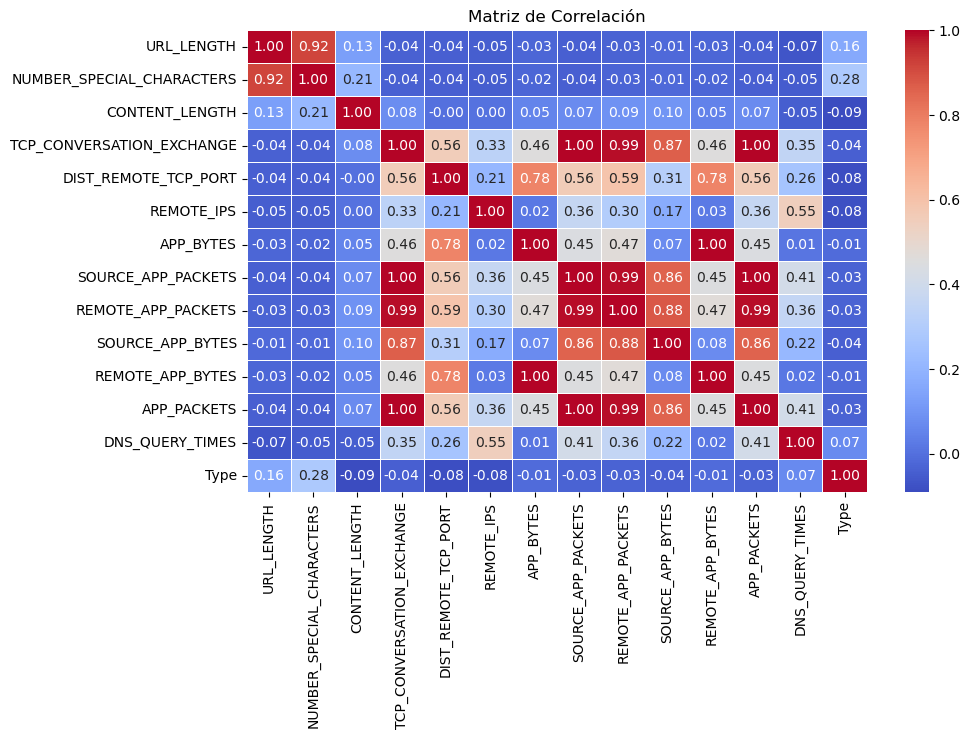

In [12]:
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación")
plt.show()

In [6]:
# Your comment here
""podriamos eliminar :
NUMERICAL_SPECIAL_CHARACTERES
SOURCE_APP_PACKETS
REMOTE_APP_PACKETS
SOURCE_APP_BYTES
APP_PACKETS"

# Challenge 2 - Remove Column Collinearity.

From the heatmap you created, you should have seen at least 3 columns that can be removed due to high collinearity. Remove these columns from the dataset.

Note that you should remove as few columns as you can. You don't have to remove all the columns at once. But instead, try removing one column, then produce the heatmap again to determine if additional columns should be removed. As long as the dataset no longer contains columns that are correlated for over 90%, you can stop. Also, keep in mind when two columns have high collinearity, you only need to remove one of them but not both.

In the cells below, remove as few columns as you can to eliminate the high collinearity in the dataset. Make sure to comment on your way so that the instructional team can learn about your thinking process which allows them to give feedback. At the end, print the heatmap again.

In [4]:
# Seleccionar solo columnas numéricas
numeric_cols = websites.select_dtypes(include=np.number)

In [9]:
# Your code here
numeric = numeric_cols.drop(columns=['TCP_CONVERSATION_EXCHANGE'])
numeric.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1781 entries, 0 to 1780
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   URL_LENGTH                 1781 non-null   int64  
 1   NUMBER_SPECIAL_CHARACTERS  1781 non-null   int64  
 2   CONTENT_LENGTH             969 non-null    float64
 3   DIST_REMOTE_TCP_PORT       1781 non-null   int64  
 4   REMOTE_IPS                 1781 non-null   int64  
 5   APP_BYTES                  1781 non-null   int64  
 6   SOURCE_APP_PACKETS         1781 non-null   int64  
 7   REMOTE_APP_PACKETS         1781 non-null   int64  
 8   SOURCE_APP_BYTES           1781 non-null   int64  
 9   REMOTE_APP_BYTES           1781 non-null   int64  
 10  APP_PACKETS                1781 non-null   int64  
 11  DNS_QUERY_TIMES            1780 non-null   float64
 12  Type                       1781 non-null   int64  
dtypes: float64(2), int64(11)
memory usage: 181.0 KB


In [10]:
# Calcular la matriz de correlación
correlation_matrix = numeric.corr()

<Figure size 1200x1000 with 0 Axes>

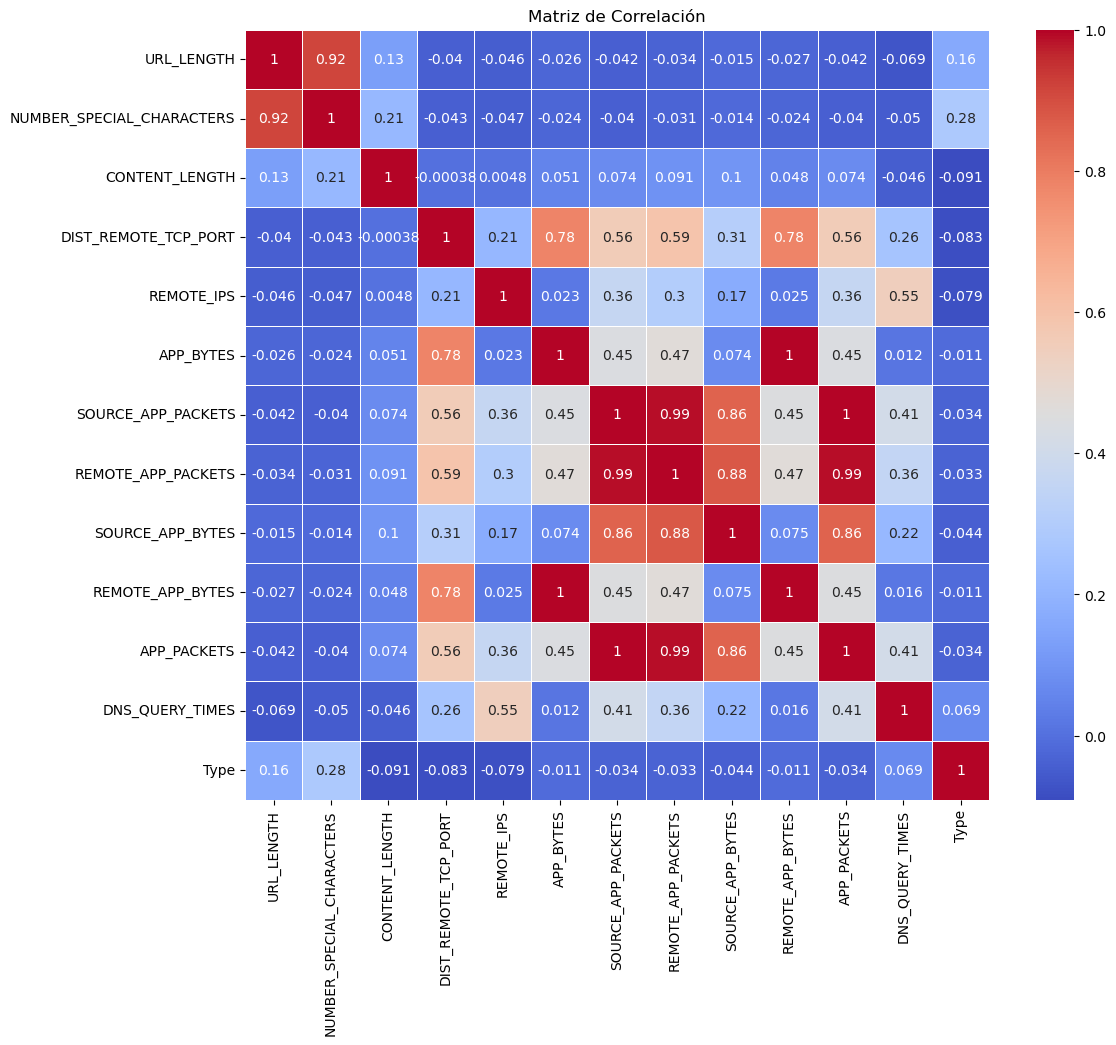

In [13]:
# Crear el mapa de calor
import seaborn as sns
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación')
plt.show()

In [14]:
# Your code here
numeric2 = numeric.drop(columns=["SOURCE_APP_PACKETS"])
numeric2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1781 entries, 0 to 1780
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   URL_LENGTH                 1781 non-null   int64  
 1   NUMBER_SPECIAL_CHARACTERS  1781 non-null   int64  
 2   CONTENT_LENGTH             969 non-null    float64
 3   DIST_REMOTE_TCP_PORT       1781 non-null   int64  
 4   REMOTE_IPS                 1781 non-null   int64  
 5   APP_BYTES                  1781 non-null   int64  
 6   REMOTE_APP_PACKETS         1781 non-null   int64  
 7   SOURCE_APP_BYTES           1781 non-null   int64  
 8   REMOTE_APP_BYTES           1781 non-null   int64  
 9   APP_PACKETS                1781 non-null   int64  
 10  DNS_QUERY_TIMES            1780 non-null   float64
 11  Type                       1781 non-null   int64  
dtypes: float64(2), int64(10)
memory usage: 167.1 KB


In [15]:
# Calcular la matriz de correlación
correlation_matrix2 = numeric2.corr()

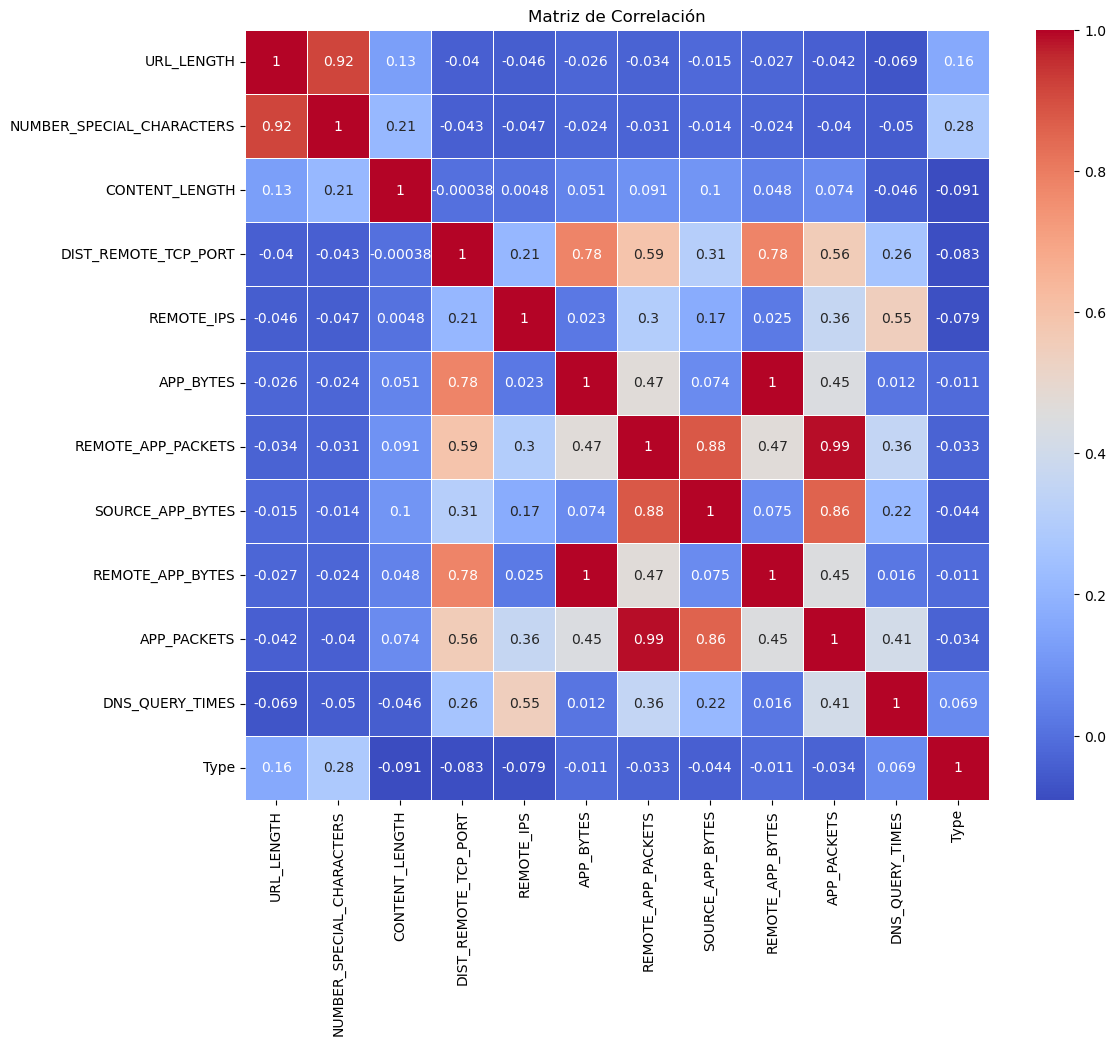

In [16]:
# Crear el mapa de calor
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix2, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación')
plt.show()

In [17]:
# Your code here
numeric3 = correlation_matrix2.drop(columns=["REMOTE_APP_BYTES"])
numeric3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12 entries, URL_LENGTH to Type
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   URL_LENGTH                 12 non-null     float64
 1   NUMBER_SPECIAL_CHARACTERS  12 non-null     float64
 2   CONTENT_LENGTH             12 non-null     float64
 3   DIST_REMOTE_TCP_PORT       12 non-null     float64
 4   REMOTE_IPS                 12 non-null     float64
 5   APP_BYTES                  12 non-null     float64
 6   REMOTE_APP_PACKETS         12 non-null     float64
 7   SOURCE_APP_BYTES           12 non-null     float64
 8   APP_PACKETS                12 non-null     float64
 9   DNS_QUERY_TIMES            12 non-null     float64
 10  Type                       12 non-null     float64
dtypes: float64(11)
memory usage: 1.4+ KB


In [18]:
# Calcular la matriz de correlación
correlation_matrix3 = numeric3.corr()

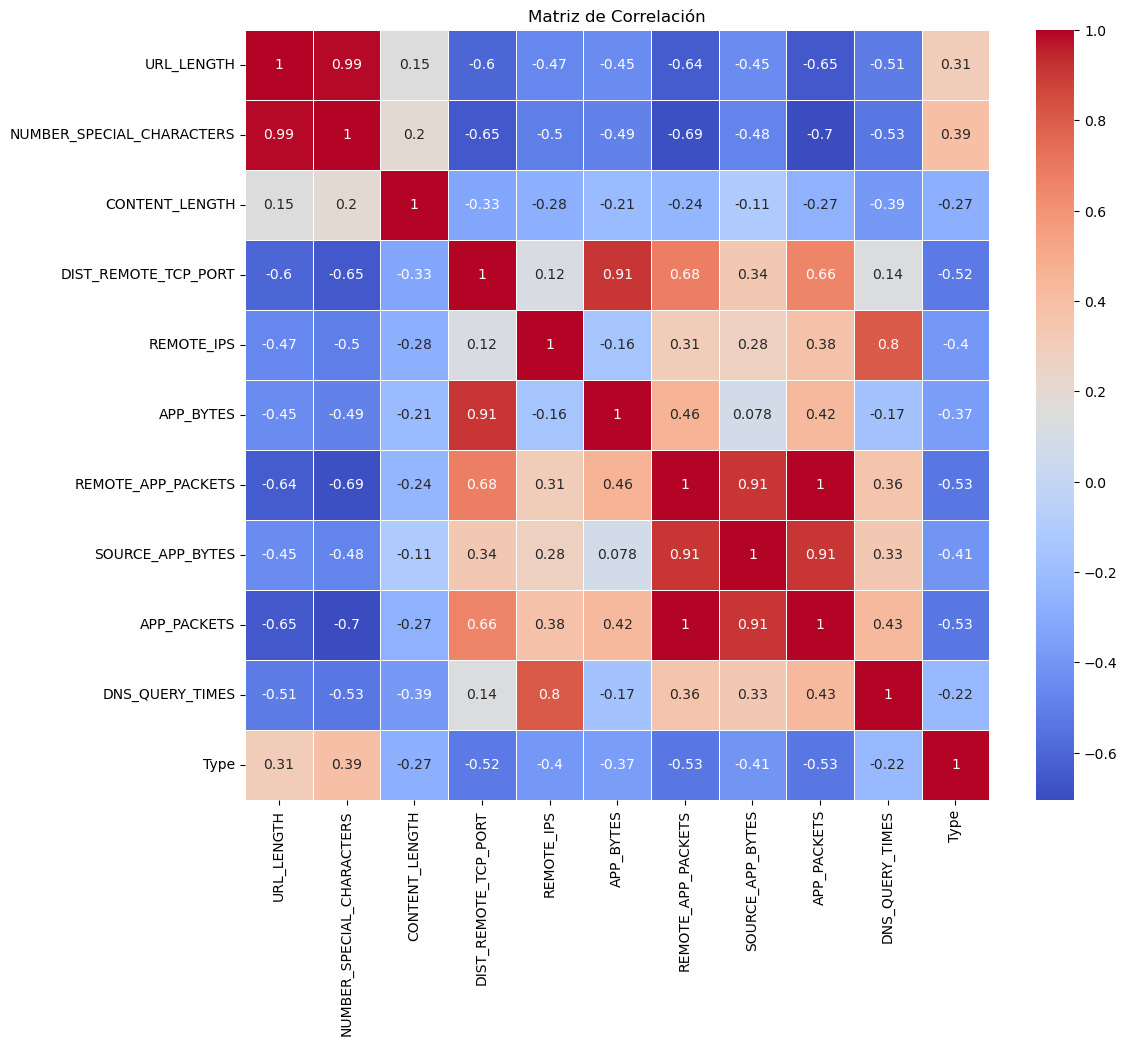

In [19]:
# Crear el mapa de calor
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix3, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación')
plt.show()

In [21]:
# Your code here
numeric4 = correlation_matrix3.drop(columns=["REMOTE_APP_PACKETS"])
numeric4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11 entries, URL_LENGTH to Type
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   URL_LENGTH                 11 non-null     float64
 1   NUMBER_SPECIAL_CHARACTERS  11 non-null     float64
 2   CONTENT_LENGTH             11 non-null     float64
 3   DIST_REMOTE_TCP_PORT       11 non-null     float64
 4   REMOTE_IPS                 11 non-null     float64
 5   APP_BYTES                  11 non-null     float64
 6   SOURCE_APP_BYTES           11 non-null     float64
 7   APP_PACKETS                11 non-null     float64
 8   DNS_QUERY_TIMES            11 non-null     float64
 9   Type                       11 non-null     float64
dtypes: float64(10)
memory usage: 1.2+ KB


In [22]:
# Calcular la matriz de correlación
correlation_matrix4 = numeric4.corr()

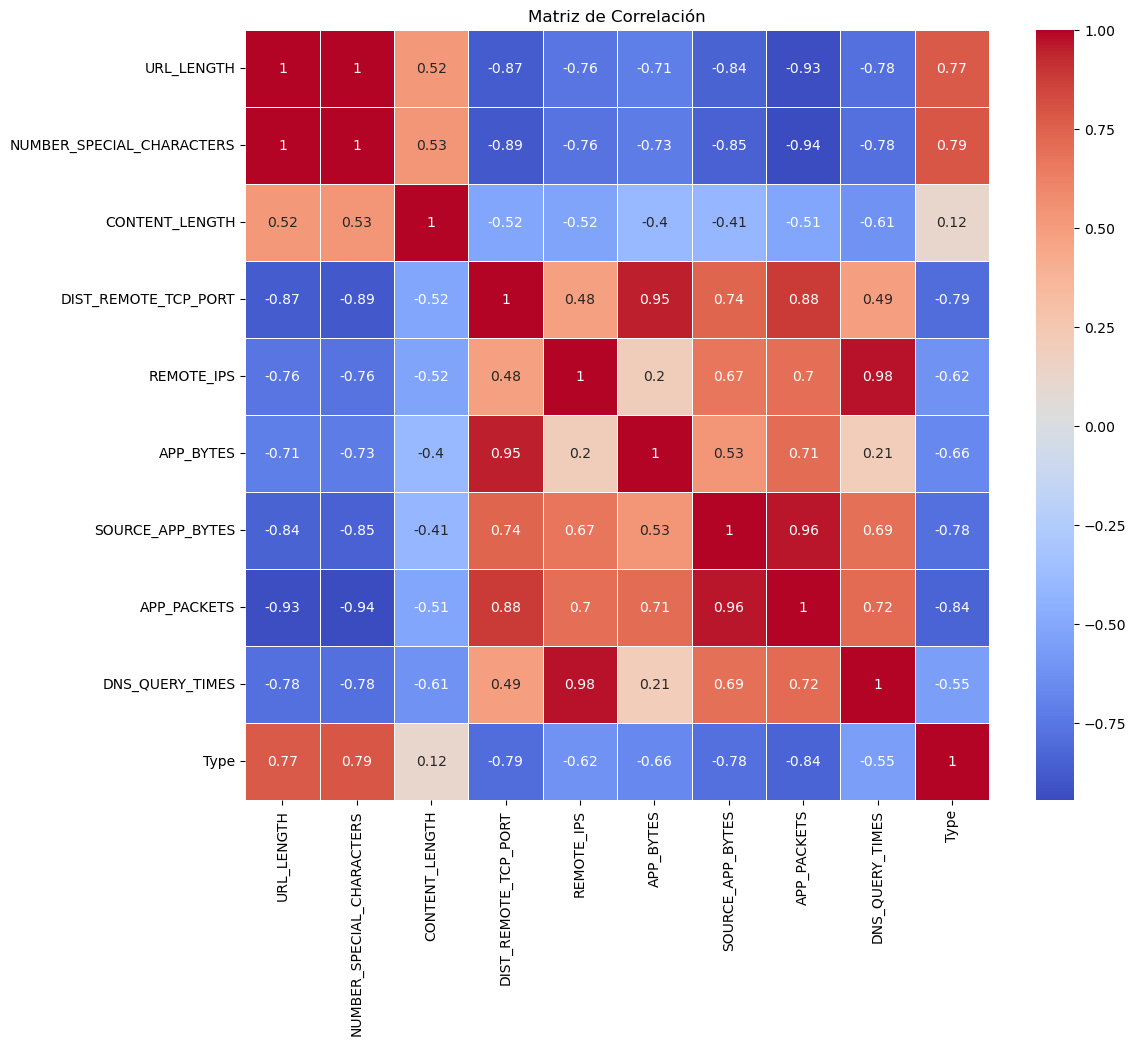

In [24]:
# Crear el mapa de calor
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix4, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación')
plt.show()

In [26]:
# Your code here
numeric5 = correlation_matrix4.drop(columns=['NUMBER_SPECIAL_CHARACTERS'])
numeric5.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10 entries, URL_LENGTH to Type
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   URL_LENGTH            10 non-null     float64
 1   CONTENT_LENGTH        10 non-null     float64
 2   DIST_REMOTE_TCP_PORT  10 non-null     float64
 3   REMOTE_IPS            10 non-null     float64
 4   APP_BYTES             10 non-null     float64
 5   SOURCE_APP_BYTES      10 non-null     float64
 6   APP_PACKETS           10 non-null     float64
 7   DNS_QUERY_TIMES       10 non-null     float64
 8   Type                  10 non-null     float64
dtypes: float64(9)
memory usage: 1.1+ KB


In [27]:
# Calcular la matriz de correlación
correlation_matrix5 = numeric5.corr()

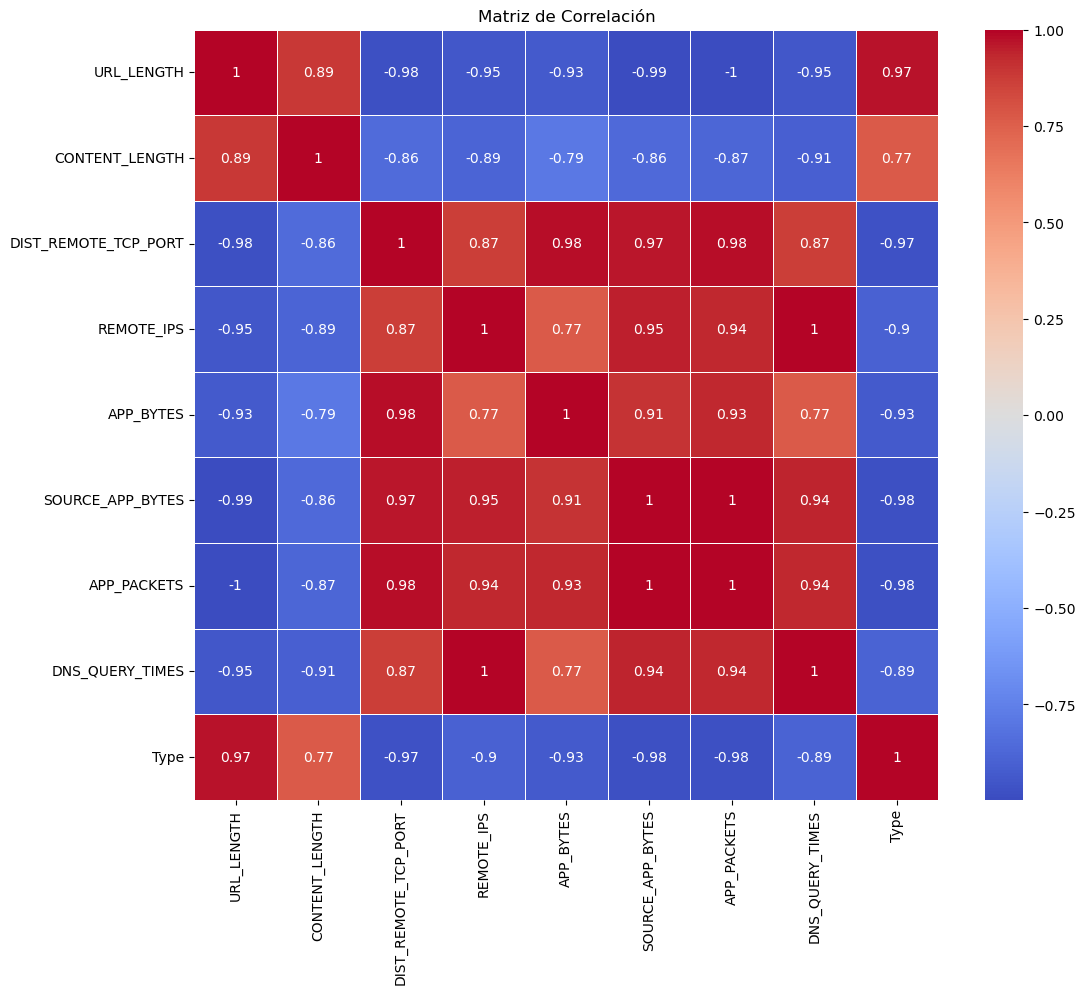

In [28]:
# Crear el mapa de calor
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix5, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación')
plt.show()

In [ ]:
#vemos que todas tienen una correlacion muy fuerte aunuqe sea positiva o negativa 

In [16]:
# Your comment here

# Calcular la matriz de correlación
corr_matrix =numeric_cols.corr()

# Definir un umbral de correlación
threshold = 0.8

# Obtener el triángulo superior de la matriz de correlación
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Identificar columnas con correlación mayor que el umbral
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > threshold)]

# Eliminar las columnas identificadas
corr_matrix.drop(to_drop, axis=1, inplace=True)
to_drop

['NUMBER_SPECIAL_CHARACTERS',
 'SOURCE_APP_PACKETS',
 'REMOTE_APP_PACKETS',
 'SOURCE_APP_BYTES',
 'REMOTE_APP_BYTES',
 'APP_PACKETS']

In [9]:
# Print heatmap again


# Challenge 3 - Handle Missing Values

The next step would be handling missing values. **We start by examining the number of missing values in each column, which you will do in the next cell.**

In [29]:
# Your code here
# Verificar valores nulos en cada columna
valores_nulos = websites.isnull().sum()
valores_nulos

URL                            0
URL_LENGTH                     0
NUMBER_SPECIAL_CHARACTERS      0
CHARSET                        7
SERVER                       176
CONTENT_LENGTH               812
WHOIS_COUNTRY                306
WHOIS_STATEPRO               362
WHOIS_REGDATE                127
WHOIS_UPDATED_DATE           139
TCP_CONVERSATION_EXCHANGE      0
DIST_REMOTE_TCP_PORT           0
REMOTE_IPS                     0
APP_BYTES                      0
SOURCE_APP_PACKETS             0
REMOTE_APP_PACKETS             0
SOURCE_APP_BYTES               0
REMOTE_APP_BYTES               0
APP_PACKETS                    0
DNS_QUERY_TIMES                1
Type                           0
dtype: int64

If you remember in the previous labs, we drop a column if the column contains a high proportion of missing values. After dropping those problematic columns, we drop the rows with missing values.

#### In the cells below, handle the missing values from the dataset. Remember to comment the rationale of your decisions.

In [31]:
# Your code here
websites_nonull=websites.drop(columns=["CONTENT_LENGTH"])
websites_nonull

,URL,URL_LENGTH,NUMBER_SPECIAL_CHARACTERS,CHARSET,SERVER,WHOIS_COUNTRY,WHOIS_STATEPRO,WHOIS_REGDATE,WHOIS_UPDATED_DATE,TCP_CONVERSATION_EXCHANGE,DIST_REMOTE_TCP_PORT,REMOTE_IPS,APP_BYTES,SOURCE_APP_PACKETS,REMOTE_APP_PACKETS,SOURCE_APP_BYTES,REMOTE_APP_BYTES,APP_PACKETS,DNS_QUERY_TIMES,Type
0,M0_109,16,7,iso-8859-1,nginx,NaN,NaN,10/10/2015 18:21,NaN,7,0,2,700,9,10,1153,832,9,2.0,1
1,B0_2314,16,6,UTF-8,Apache/2.4.10,NaN,NaN,NaN,NaN,17,7,4,1230,17,19,1265,1230,17,0.0,0
2,B0_911,16,6,us-ascii,Microsoft-HTTPAPI/2.0,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0.0,0
3,B0_113,17,6,ISO-8859-1,nginx,US,AK,7/10/1997 4:00,12/09/2013 0:45,31,22,3,3812,39,37,18784,4380,39,8.0,0
4,B0_403,17,6,UTF-8,NaN,US,TX,12/05/1996 0:00,11/04/2017 0:00,57,2,5,4278,61,62,129889,4586,61,4.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1776,M4_48,194,16,UTF-8,Apache,ES,Barcelona,17/09/2008 0:00,2/09/2016 0:00,0,0,0,0,0,3,186,0,0,0.0,1
1777,M4_41,198,17,UTF-8,Apache,ES,Barcelona,17/09/2008 0:00,2/09/2016 0:00,0,0,0,0,0,2,124,0,0,0.0,1
1778,B0_162,201,34,utf-8,Apache/2.2.16 (Debian),US,FL,15/02/1999 0:00,15/07/2015 0:00,83,2,6,6631,87,89,132181,6945,87,4.0,0
1779,B0_1152,234,34,ISO-8859-1,cloudflare-nginx,US,CA,1/04/1998 0:00,9/12/2016 0:00,0,0,0,0,0,0,0,0,0,0.0,0


In [37]:
# Sustituir valores nulos en las columnas 'WHOIS_COUNTRY' , 'WHOIS_STATEPRO' y 'SERVER' por 'no information'
websites_nonull['WHOIS_COUNTRY'] = websites_nonull['WHOIS_COUNTRY'].fillna('no information')
websites_nonull['WHOIS_STATEPRO'] = websites_nonull['WHOIS_STATEPRO'].fillna('no information')
websites_nonull['SERVER'] = websites_nonull['SERVER'].fillna('no information')
websites_nonull.isnull().sum()

URL                            0
URL_LENGTH                     0
NUMBER_SPECIAL_CHARACTERS      0
CHARSET                        7
SERVER                         0
WHOIS_COUNTRY                  0
WHOIS_STATEPRO                 0
WHOIS_REGDATE                127
WHOIS_UPDATED_DATE           139
TCP_CONVERSATION_EXCHANGE      0
DIST_REMOTE_TCP_PORT           0
REMOTE_IPS                     0
APP_BYTES                      0
SOURCE_APP_PACKETS             0
REMOTE_APP_PACKETS             0
SOURCE_APP_BYTES               0
REMOTE_APP_BYTES               0
APP_PACKETS                    0
DNS_QUERY_TIMES                1
Type                           0
dtype: int64

In [39]:
# Eliminar filas con valores nulos en las columnas 'CHARSET' , 'DNS_QUERY_TIMES','WHOIS_REGDATE' y 'WHOIS_UPDATED_DATE'
websites_nonull = websites_nonull.dropna(subset=['CHARSET', 'DNS_QUERY_TIMES'])
websites_nonull = websites_nonull.dropna(subset=['WHOIS_REGDATE', 'WHOIS_UPDATED_DATE'])
websites_nonull

,URL,URL_LENGTH,NUMBER_SPECIAL_CHARACTERS,CHARSET,SERVER,WHOIS_COUNTRY,WHOIS_STATEPRO,WHOIS_REGDATE,WHOIS_UPDATED_DATE,TCP_CONVERSATION_EXCHANGE,DIST_REMOTE_TCP_PORT,REMOTE_IPS,APP_BYTES,SOURCE_APP_PACKETS,REMOTE_APP_PACKETS,SOURCE_APP_BYTES,REMOTE_APP_BYTES,APP_PACKETS,DNS_QUERY_TIMES,Type
3,B0_113,17,6,ISO-8859-1,nginx,US,AK,7/10/1997 4:00,12/09/2013 0:45,31,22,3,3812,39,37,18784,4380,39,8.0,0
4,B0_403,17,6,UTF-8,no information,US,TX,12/05/1996 0:00,11/04/2017 0:00,57,2,5,4278,61,62,129889,4586,61,4.0,0
5,B0_2064,18,7,UTF-8,nginx,SC,Mahe,3/08/2016 14:30,3/10/2016 3:45,11,6,9,894,11,13,838,894,11,0.0,0
6,B0_462,18,6,iso-8859-1,Apache/2,US,CO,29/07/2002 0:00,1/07/2016 0:00,12,0,3,1189,14,13,8559,1327,14,2.0,0
7,B0_1128,19,6,us-ascii,Microsoft-HTTPAPI/2.0,US,FL,18/03/1997 0:00,19/03/2017 0:00,0,0,0,0,0,0,0,0,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1776,M4_48,194,16,UTF-8,Apache,ES,Barcelona,17/09/2008 0:00,2/09/2016 0:00,0,0,0,0,0,3,186,0,0,0.0,1
1777,M4_41,198,17,UTF-8,Apache,ES,Barcelona,17/09/2008 0:00,2/09/2016 0:00,0,0,0,0,0,2,124,0,0,0.0,1
1778,B0_162,201,34,utf-8,Apache/2.2.16 (Debian),US,FL,15/02/1999 0:00,15/07/2015 0:00,83,2,6,6631,87,89,132181,6945,87,4.0,0
1779,B0_1152,234,34,ISO-8859-1,cloudflare-nginx,US,CA,1/04/1998 0:00,9/12/2016 0:00,0,0,0,0,0,0,0,0,0,0.0,0


In [12]:
# Your comment here
"hemos decidido Sustituir valores nulos en las columnas 'WHOIS_COUNTRY' , 'WHOIS_STATEPRO' y 'SERVER' por 'no information' al no ser numericas resulta mas facil"
"# hemos Eliminar filas con valores nulos en las columnas 'CHARSET' , 'DNS_QUERY_TIMES','WHOIS_REGDATE' y 'WHOIS_UPDATED_DATE' al ser pocas y no querer falcear los datos, la ideha ha sido eliminarlas 

#### Again, examine the number of missing values in each column. 

If all cleaned, proceed. Otherwise, go back and do more cleaning.

In [41]:
# Examine missing values in each column
websites_nonull.isnull().sum()

URL                          0
URL_LENGTH                   0
NUMBER_SPECIAL_CHARACTERS    0
CHARSET                      0
SERVER                       0
WHOIS_COUNTRY                0
WHOIS_STATEPRO               0
WHOIS_REGDATE                0
WHOIS_UPDATED_DATE           0
TCP_CONVERSATION_EXCHANGE    0
DIST_REMOTE_TCP_PORT         0
REMOTE_IPS                   0
APP_BYTES                    0
SOURCE_APP_PACKETS           0
REMOTE_APP_PACKETS           0
SOURCE_APP_BYTES             0
REMOTE_APP_BYTES             0
APP_PACKETS                  0
DNS_QUERY_TIMES              0
Type                         0
dtype: int64

# Challenge 4 - Handle `WHOIS_*` Categorical Data

There are several categorical columns we need to handle. These columns are:

* `URL`
* `CHARSET`
* `SERVER`
* `WHOIS_COUNTRY`
* `WHOIS_STATEPRO`
* `WHOIS_REGDATE`
* `WHOIS_UPDATED_DATE`

How to handle string columns is always case by case. Let's start by working on `WHOIS_COUNTRY`. Your steps are:

1. List out the unique values of `WHOIS_COUNTRY`.
1. Consolidate the country values with consistent country codes. For example, the following values refer to the same country and should use consistent country code:
    * `CY` and `Cyprus`
    * `US` and `us`
    * `SE` and `se`
    * `GB`, `United Kingdom`, and `[u'GB'; u'UK']`

#### In the cells below, fix the country values as intructed above.

In [62]:
print(type(unique_countries)) 

<class 'numpy.ndarray'>


In [65]:
# Your code here
unique_countries = websites_nonull['WHOIS_COUNTRY'].unique()
unique_countries

array(['US', 'SC', 'GB', 'NO INFORMATION', 'UK', 'RU', 'AU', 'CA', 'PA',
       'SE', 'IN', 'LU', 'TH', "[U'GB'; U'UK']", 'FR', 'NL', 'UG', 'JP',
       'CN', 'SI', 'IL', 'KY', 'AT', 'CZ', 'PH', 'BE', 'NO', 'TR', 'LV',
       'DE', 'ES', 'KR', 'HK', 'UA', 'CH', 'BS', 'PK', 'IT', 'CYPRUS',
       'BY', 'AE', 'IE', 'UY', 'KG'], dtype=object)

In [72]:
websites_nonull['WHOIS_COUNTRY'] = websites_nonull['WHOIS_COUNTRY'].str.upper().str.strip()

In [68]:
websites_nonull['WHOIS_COUNTRY'] = websites_nonull['WHOIS_COUNTRY'].replace({'CYPRUS': 'CY'})

In [69]:
print(websites_nonull['WHOIS_COUNTRY'].unique())  # Ver valores únicos después del cambi

['US' 'SC' 'GB' 'NO INFORMATION' 'UK' 'RU' 'AU' 'CA' 'PA' 'SE' 'IN' 'LU'
 'TH' "[U'GB'; U'UK']" 'FR' 'NL' 'UG' 'JP' 'CN' 'SI' 'IL' 'KY' 'AT' 'CZ'
 'PH' 'BE' 'NO' 'TR' 'LV' 'DE' 'ES' 'KR' 'HK' 'UA' 'CH' 'BS' 'PK' 'IT'
 'CY' 'BY' 'AE' 'IE' 'UY' 'KG']


In [70]:
websites_nonull['WHOIS_COUNTRY'] = websites_nonull['WHOIS_COUNTRY'].replace({"[U'GB'; U'UK']": 'United Kingdom'})

In [73]:
print(websites_nonull['WHOIS_COUNTRY'].unique())

['US' 'SC' 'GB' 'NO INFORMATION' 'UK' 'RU' 'AU' 'CA' 'PA' 'SE' 'IN' 'LU'
 'TH' 'UNITED KINGDOM' 'FR' 'NL' 'UG' 'JP' 'CN' 'SI' 'IL' 'KY' 'AT' 'CZ'
 'PH' 'BE' 'NO' 'TR' 'LV' 'DE' 'ES' 'KR' 'HK' 'UA' 'CH' 'BS' 'PK' 'IT'
 'CY' 'BY' 'AE' 'IE' 'UY' 'KG']


Since we have fixed the country values, can we convert this column to ordinal now?

Not yet. If you reflect on the previous labs how we handle categorical columns, you probably remember we ended up dropping a lot of those columns because there are too many unique values. Too many unique values in a column is not desirable in machine learning because it makes prediction inaccurate. But there are workarounds under certain conditions. One of the fixable conditions is:

#### If a limited number of values account for the majority of data, we can retain these top values and re-label all other rare values.

The `WHOIS_COUNTRY` column happens to be this case. You can verify it by print a bar chart of the `value_counts` in the next cell to verify:

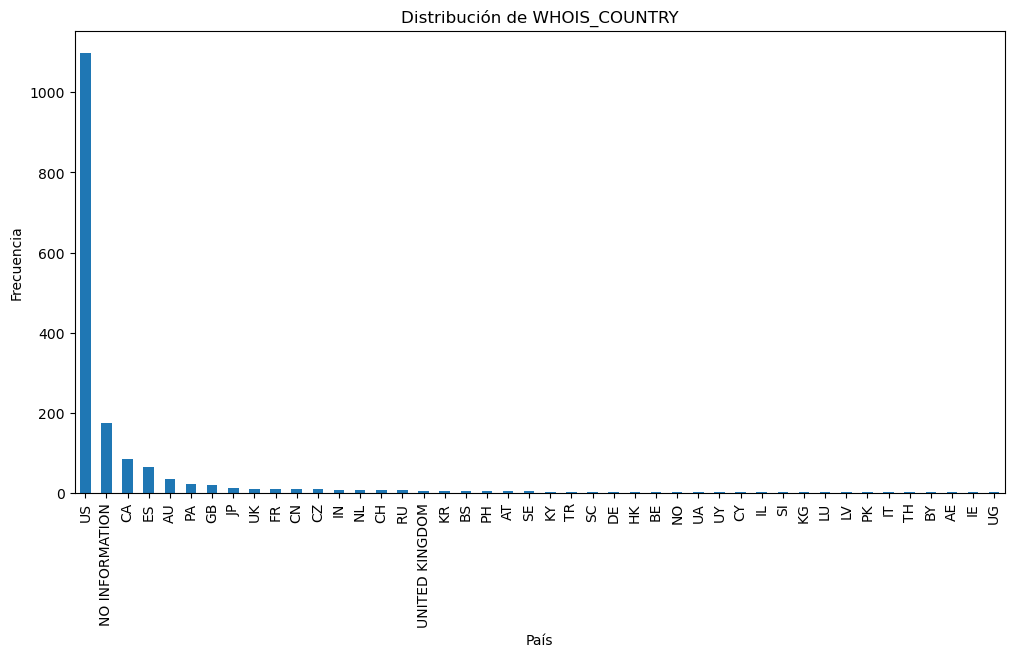

In [74]:
# Your code here
# Contar los valores únicos en la columna WHOIS_COUNTRY
country_counts = websites_nonull['WHOIS_COUNTRY'].value_counts()

# Crear un gráfico de barras
plt.figure(figsize=(12, 6))
country_counts.plot(kind='bar')
plt.title('Distribución de WHOIS_COUNTRY')
plt.xlabel('País')
plt.ylabel('Frecuencia')
plt.show()


#### After verifying, now let's keep the top 10 values of the column and re-label other columns with `OTHER`.

In [76]:
# Your code here
#Obtener los 10 valores más frecuentes:
top_10_countries = websites_nonull['WHOIS_COUNTRY'].value_counts().nlargest(10).index


In [77]:
#Re-etiquetar los valores menos frecuentes como "OTHER":
websites_nonull.loc[:, 'WHOIS_COUNTRY'] = websites_nonull['WHOIS_COUNTRY'].apply(lambda x: x if x in top_10_countries else 'OTHER')

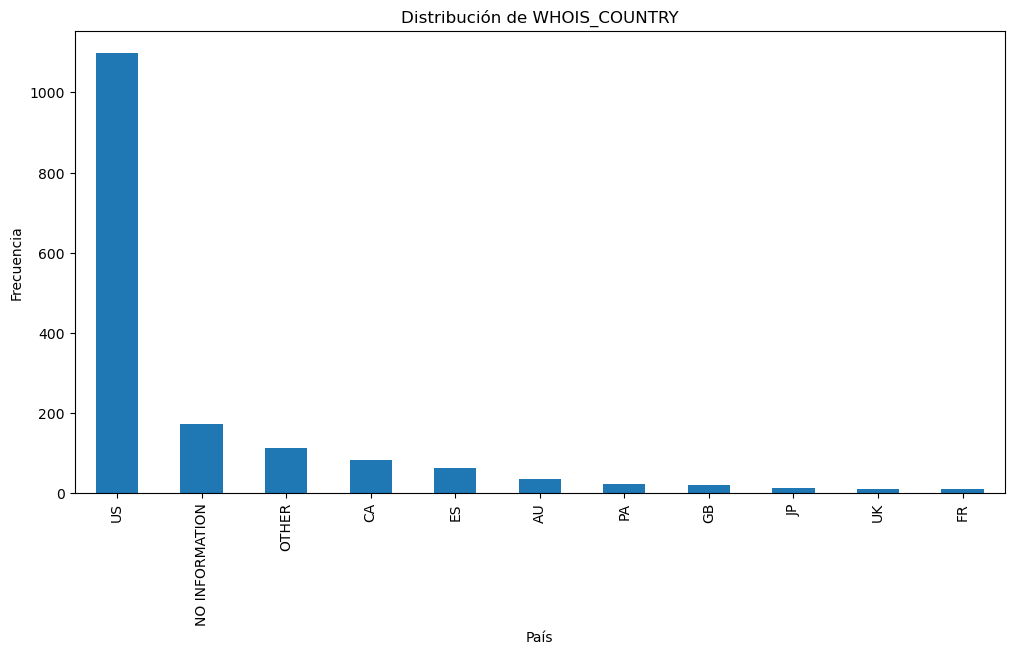

In [78]:
# Contar los valores únicos en la columna WHOIS_COUNTRY
country_counts2 = websites_nonull['WHOIS_COUNTRY'].value_counts()

# Crear un gráfico de barras
plt.figure(figsize=(12, 6))
country_counts2.plot(kind='bar')
plt.title('Distribución de WHOIS_COUNTRY')
plt.xlabel('País')
plt.ylabel('Frecuencia')
plt.show()

Now since `WHOIS_COUNTRY` has been re-labelled, we don't need `WHOIS_STATEPRO` any more because the values of the states or provinces may not be relevant any more. We'll drop this column.

In addition, we will also drop `WHOIS_REGDATE` and `WHOIS_UPDATED_DATE`. These are the registration and update dates of the website domains. Not of our concerns.

#### In the next cell, drop `['WHOIS_STATEPRO', 'WHOIS_REGDATE', 'WHOIS_UPDATED_DATE']`.

In [79]:
# Your code here
websites_nonull.drop(columns=['WHOIS_STATEPRO', 'WHOIS_REGDATE', 'WHOIS_UPDATED_DATE'], inplace=True)
websites_nonull

,URL,URL_LENGTH,NUMBER_SPECIAL_CHARACTERS,CHARSET,SERVER,WHOIS_COUNTRY,TCP_CONVERSATION_EXCHANGE,DIST_REMOTE_TCP_PORT,REMOTE_IPS,APP_BYTES,SOURCE_APP_PACKETS,REMOTE_APP_PACKETS,SOURCE_APP_BYTES,REMOTE_APP_BYTES,APP_PACKETS,DNS_QUERY_TIMES,Type
3,B0_113,17,6,ISO-8859-1,nginx,US,31,22,3,3812,39,37,18784,4380,39,8.0,0
4,B0_403,17,6,UTF-8,no information,US,57,2,5,4278,61,62,129889,4586,61,4.0,0
5,B0_2064,18,7,UTF-8,nginx,OTHER,11,6,9,894,11,13,838,894,11,0.0,0
6,B0_462,18,6,iso-8859-1,Apache/2,US,12,0,3,1189,14,13,8559,1327,14,2.0,0
7,B0_1128,19,6,us-ascii,Microsoft-HTTPAPI/2.0,US,0,0,0,0,0,0,0,0,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1776,M4_48,194,16,UTF-8,Apache,ES,0,0,0,0,0,3,186,0,0,0.0,1
1777,M4_41,198,17,UTF-8,Apache,ES,0,0,0,0,0,2,124,0,0,0.0,1
1778,B0_162,201,34,utf-8,Apache/2.2.16 (Debian),US,83,2,6,6631,87,89,132181,6945,87,4.0,0
1779,B0_1152,234,34,ISO-8859-1,cloudflare-nginx,US,0,0,0,0,0,0,0,0,0,0.0,0


# Challenge 5 - Handle Remaining Categorical Data & Convert to Ordinal

Now print the `dtypes` of the data again. Besides `WHOIS_COUNTRY` which we already fixed, there should be 3 categorical columns left: `URL`, `CHARSET`, and `SERVER`.

In [80]:
# Your code here
websites_nonull.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1634 entries, 3 to 1780
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   URL                        1634 non-null   object 
 1   URL_LENGTH                 1634 non-null   int64  
 2   NUMBER_SPECIAL_CHARACTERS  1634 non-null   int64  
 3   CHARSET                    1634 non-null   object 
 4   SERVER                     1634 non-null   object 
 5   WHOIS_COUNTRY              1634 non-null   object 
 6   TCP_CONVERSATION_EXCHANGE  1634 non-null   int64  
 7   DIST_REMOTE_TCP_PORT       1634 non-null   int64  
 8   REMOTE_IPS                 1634 non-null   int64  
 9   APP_BYTES                  1634 non-null   int64  
 10  SOURCE_APP_PACKETS         1634 non-null   int64  
 11  REMOTE_APP_PACKETS         1634 non-null   int64  
 12  SOURCE_APP_BYTES           1634 non-null   int64  
 13  REMOTE_APP_BYTES           1634 non-null   int64  
 1

#### `URL` is easy. We'll simply drop it because it has too many unique values that there's no way for us to consolidate.

In [82]:
# Your code here
# Eliminar la columna 'URL'
website = websites_nonull.drop(columns=['URL'])

website.columns

Index(['URL_LENGTH', 'NUMBER_SPECIAL_CHARACTERS', 'CHARSET', 'SERVER',
       'WHOIS_COUNTRY', 'TCP_CONVERSATION_EXCHANGE', 'DIST_REMOTE_TCP_PORT',
       'REMOTE_IPS', 'APP_BYTES', 'SOURCE_APP_PACKETS', 'REMOTE_APP_PACKETS',
       'SOURCE_APP_BYTES', 'REMOTE_APP_BYTES', 'APP_PACKETS',
       'DNS_QUERY_TIMES', 'Type'],
      dtype='object')

#### Print the unique value counts of `CHARSET`. You see there are only a few unique values. So we can keep it as it is.

In [84]:
# Your code here
charset_counts = website['CHARSET'].value_counts()
print(charset_counts)

CHARSET
UTF-8           605
ISO-8859-1      408
utf-8           357
us-ascii        144
iso-8859-1      117
windows-1251      1
ISO-8859          1
windows-1252      1
Name: count, dtype: int64


`SERVER` is a little more complicated. Print its unique values and think about how you can consolidate those values.

#### Before you think of your own solution, don't read the instructions that come next.

In [85]:
# Your code here
server_counts = website['SERVER'].value_counts()
print(server_counts)

SERVER
Apache                    356
no information            170
nginx                     160
Microsoft-HTTPAPI/2.0     103
cloudflare-nginx           91
                         ... 
mw2225.codfw.wmnet          1
nginx/0.8.54                1
mw2109.codfw.wmnet          1
openresty/1.11.2.2          1
Apache/2.2.16 (Debian)      1
Name: count, Length: 226, dtype: int64


![Think Hard](../images/think-hard.jpg)

In [24]:
# Your comment here


Although there are so many unique values in the `SERVER` column, there are actually only 3 main server types: `Microsoft`, `Apache`, and `nginx`. Just check if each `SERVER` value contains any of those server types and re-label them. For `SERVER` values that don't contain any of those substrings, label with `Other`.

At the end, your `SERVER` column should only contain 4 unique values: `Microsoft`, `Apache`, `nginx`, and `Other`.

In [86]:
# Your code here
def label_server_type(server):
    if 'Microsoft' in server:
        return 'Microsoft'
    elif 'Apache' in server:
        return 'Apache'
    elif 'nginx' in server:
        return 'nginx'
    else:
        return 'Other'

websites_nonull['SERVER'] = websites_nonull['SERVER'].apply(lambda x: label_server_type(str(x)))

print(websites_nonull['SERVER'].unique())

['nginx' 'Other' 'Apache' 'Microsoft']


In [26]:
# Count `SERVER` value counts here


OK, all our categorical data are fixed now. **Let's convert them to ordinal data using Pandas' `get_dummies` function ([documentation](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.get_dummies.html)).** Make sure you drop the categorical columns by passing `drop_first=True` to `get_dummies` as we don't need them any more. **Also, assign the data with dummy values to a new variable `website_dummy`.**

In [88]:
# Your code here
# Convertir las columnas categóricas a datos ordinales usando get_dummies
website_dummy = pd.get_dummies(website, drop_first=True)

Now, inspect `website_dummy` to make sure the data and types are intended - there shouldn't be any categorical columns at this point.

In [89]:
# Your code here
# Verificar las columnas del nuevo DataFrame
website_dummy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1634 entries, 3 to 1780
Columns: 255 entries, URL_LENGTH to WHOIS_COUNTRY_US
dtypes: bool(242), float64(1), int64(12)
memory usage: 564.9 KB


# Challenge 6 - Modeling, Prediction, and Evaluation

We'll start off this section by splitting the data to train and test. **Name your 4 variables `X_train`, `X_test`, `y_train`, and `y_test`. Select 80% of the data for training and 20% for testing.**

In [91]:
from sklearn.model_selection import train_test_split

X = website_dummy.drop(columns=['Type'])  # Features
y = website_dummy['Type']  # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the shape of the splits
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1307, 254)
X_test shape: (327, 254)
y_train shape: (1307,)
y_test shape: (327,)


#### In this lab, we will try two different models and compare our results.

The first model we will use in this lab is logistic regression. We have previously learned about logistic regression as a classification algorithm. In the cell below, load `LogisticRegression` from scikit-learn and initialize the model.

In [93]:
# Your code here:
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression()
print(logistic_model)


LogisticRegression()


Next, fit the model to our training data. We have already separated our data into 4 parts. Use those in your model.

In [94]:
# Your code here:
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train, y_train)


C:\Users\paul_\miniconda3\envs\m3_env\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

finally, import `confusion_matrix` and `accuracy_score` from `sklearn.metrics` and fit our testing data. Assign the fitted data to `y_pred` and print the confusion matrix as well as the accuracy score

In [95]:
# Your code here:
from sklearn.metrics import confusion_matrix, accuracy_score

# Predecir los valores para los datos de prueba
y_pred = logistic_model.predict(X_test)

# Imprimir la matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)
print("Matriz de Confusión:")
print(conf_matrix)

# Imprimir la precisión del modelo
accuracy = accuracy_score(y_test, y_pred)
print("Precisión del Modelo:")
print(accuracy)


Matriz de Confusión:
[[289   1]
 [ 15  22]]
Precisión del Modelo:
0.9510703363914373


What are your thoughts on the performance of the model? Write your conclusions below.

In [33]:
# Your conclusions here:
"hemos conseguido una precisión de el 95%"


#### Our second algorithm is is K-Nearest Neighbors. 

Though is it not required, we will fit a model using the training data and then test the performance of the model using the testing data. Start by loading `KNeighborsClassifier` from scikit-learn and then initializing and fitting the model. We'll start off with a model where k=3.

In [96]:
# Your code here:

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=3)

knn_model.fit(X_train, y_train)

print(knn_model)

KNeighborsClassifier(n_neighbors=3)


To test your model, compute the predicted values for the testing sample and print the confusion matrix as well as the accuracy score.

In [97]:
# Your code here:
y_pred = knn_model.predict(X_test)

# Imprimir la matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)
print("Matriz de Confusión (k=3):")
print(conf_matrix)

# Imprimir la precisión del modelo
accuracy = accuracy_score(y_test, y_pred)
print("Precisión del Modelo (k=3):")
print(accuracy)


Matriz de Confusión (k=3):
[[289   1]
 [ 11  26]]
Precisión del Modelo (k=3):
0.963302752293578


#### We'll create another K-Nearest Neighbors model with k=5. 

Initialize and fit the model below and print the confusion matrix and the accuracy score.

In [98]:
# Your code here:
knn_model_k5 = KNeighborsClassifier(n_neighbors=5)

knn_model_k5.fit(X_train, y_train)

y_pred_k5 = knn_model_k5.predict(X_test)

conf_matrix_k5 = confusion_matrix(y_test, y_pred_k5)
print("Matriz de Confusión (k=5):")
print(conf_matrix_k5)

accuracy_k5 = accuracy_score(y_test, y_pred_k5)
print("Precisión del Modelo (k=5):")
print(accuracy_k5)


Matriz de Confusión (k=5):
[[288   2]
 [ 12  25]]
Precisión del Modelo (k=5):
0.9571865443425076


Did you see an improvement in the confusion matrix when increasing k to 5? Did you see an improvement in the accuracy score? Write your conclusions below.

In [37]:
# Your conclusions here:
"Se observa que con k=3 tiene una mejor precisión"


# Bonus Challenge - Feature Scaling

Problem-solving in machine learning is iterative. You can improve your model prediction with various techniques (there is a sweetspot for the time you spend and the improvement you receive though). Now you've completed only one iteration of ML analysis. There are more iterations you can conduct to make improvements. In order to be able to do that, you will need deeper knowledge in statistics and master more data analysis techniques. In this bootcamp, we don't have time to achieve that advanced goal. But you will make constant efforts after the bootcamp to eventually get there.

However, now we do want you to learn one of the advanced techniques which is called *feature scaling*. The idea of feature scaling is to standardize/normalize the range of independent variables or features of the data. This can make the outliers more apparent so that you can remove them. This step needs to happen during Challenge 6 after you split the training and test data because you don't want to split the data again which makes it impossible to compare your results with and without feature scaling. For general concepts about feature scaling, click [here](https://en.wikipedia.org/wiki/Feature_scaling). To read deeper, click [here](https://medium.com/greyatom/why-how-and-when-to-scale-your-features-4b30ab09db5e).

In the next cell, attempt to improve your model prediction accuracy by means of feature scaling. A library you can utilize is `sklearn.preprocessing.RobustScaler` ([documentation](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.RobustScaler.html)). You'll use the `RobustScaler` to fit and transform your `X_train`, then transform `X_test`. You will use logistic regression to fit and predict your transformed data and obtain the accuracy score in the same way. Compare the accuracy score with your normalized data with the previous accuracy data. Is there an improvement?

In [38]:
# Your code here